# NB01 — EDA and feature engineering

**Input:** NB00's `panel_long.parquet` and `macro_q.parquet`, through `container.panel_store()`.

**Output:** three automated profiles, an audit, target and segment analyses, feature files per target variable, and a decision table — all logged to W&B.

The sections follow the eight-step framework of A. Whaval's "EDA Best Practices: A Step-by-Step Framework" (Medium); every section opens with the question it answers and closes with the answer.
Every collaborator comes from the DI container; this notebook only orchestrates (spec R10, F17).
Specs: `docs/specs/eda-feature-engineering.md`, `docs/specs/eda-actionable-framework.md`.

## Setup: choose the target, load panels

`TARGET_VARIABLE` picks what to forecast: revenue, gross profit, opex, EBITDA or free cash flow (spec F2).
Companies and targets with an open ingestion defect are held back by `config/ingestion_defects.yaml` (spec F16): today COP is excluded and opex is blocked, both until `docs/specs/ingestion-defects-cop-ge.md` lands. Deleting an entry there lifts it.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd

from app.data.schema import COMPANY_VALUE_COLUMNS, MACRO_COLUMNS
from app.injections import configure_container
from app.services.diagnostics import (
    DecisionInputs,
    median_timeline,
    pooled_yoy_changes,
    profile_frame,
    seasonal_profile,
    segment_frame,
)
from app.services.features import (
    FeatureGroup,
    FeatureSpec,
    TargetArm,
    TargetTransformer,
    TargetVariable,
    default_arm,
    feature_groups_by_column,
)
from app.services.tracking import RunConfig, run_name

container = configure_container()
tracker = container.experiment_tracker()
diagnostics_service = container.diagnostics_service()
feature_store = container.feature_store()
eda_figures = container.eda_figures()

# The forecast target: REVENUE, GROSS_PROFIT, OPEX, EBITDA or FREE_CASH_FLOW.
TARGET_VARIABLE = TargetVariable.REVENUE
# Features and targets are built for the chosen variable, not revenue by default.
feature_service = container.feature_service(
    builder__spec=FeatureSpec(target_variable=TARGET_VARIABLE)
)

ingestion_defects = container.ingestion_defects()
ingestion_defects.require_selectable(TARGET_VARIABLE)

NB00_COMPANIES = 60
QUARTERS = 81
panels = ingestion_defects.without_excluded(container.panel_store().load_consolidated())
n_rows = sum(len(panel) for panel in panels.values())
n_pre_listing = sum(int(panel["pre_listing"].sum()) for panel in panels.values())

assert len(panels) == NB00_COMPANIES - len(ingestion_defects.excluded_companies)  # A1
assert all(len(panel) == QUARTERS for panel in panels.values())  # A1
assert all(
    {"covid", "structural_break", "pre_listing"} <= set(p.columns)
    for p in panels.values()
)

# The chosen variable is always diagnosed: § 9's forecastable rule reads it.
TARGETS = list(
    dict.fromkeys([
        TARGET_VARIABLE.value,
        "revenue_usd_m",
        "operating_income_usd_m",
        "ebitda_usd_m",
        "free_cash_flow_usd_m",
    ])
)

2026-10-02 20:29:36.702 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 20:29:36.703 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


### Series diagnostics (used by § 4, § 6 and § 7)

Stationarity, seasonality and noise for each company's target series, and the seasonality regimes they imply; computed once here because § 4 counts the regimes and § 6 compares them.

In [3]:
diagnostics = diagnostics_service.diagnose_panel(panels, TARGETS)
revenue = diagnostics.query("variable == 'revenue_usd_m'").set_index("ticker")

# One-quarter interior gaps are filled for diagnosis (spec D10): TSLA and BBY each
# gain one; ADBE and ORCL start a quarter late, which is never filled.
SHORT_HISTORIES = {"TSLA": 75, "ADBE": 80, "ORCL": 80}
assert len(diagnostics) == len(panels) * len(TARGETS)  # A2
assert revenue.loc[list(SHORT_HISTORIES), "n_obs"].tolist() == list(
    SHORT_HISTORIES.values()
)  # A2
assert revenue["n_obs"].drop(list(SHORT_HISTORIES)).eq(QUARTERS).all()  # A2

regimes = diagnostics_service.seasonality_regimes(diagnostics, variable="revenue_usd_m")
sector_sensitivity = (
    diagnostics_service
    .growth_macro_correlations(panels, variable="revenue_usd_m")
    .groupby("sector")
    .mean(numeric_only=True)
)
diagnostics.groupby(["variable", "status"]).size()

variable                status           
ebitda_usd_m            insufficient_data     1
                        ok                   58
free_cash_flow_usd_m    ok                   59
operating_income_usd_m  ok                   59
revenue_usd_m           ok                   59
dtype: int64

## 0. Automated profile

**Question:** What does the pooled panel look like column by column — types, missing values, distributions, correlations, alerts — and did anything shift from 2020 onward?

In [4]:
auto_profiler = container.auto_profiler()
pooled_panel = pd.concat(panels.values(), ignore_index=True)
before_2020 = pooled_panel["date"] < pd.Timestamp("2020-01-01")

panel_report = auto_profiler.profile(
    profile_frame(pooled_panel),
    title="NB01 pooled panel",
    name="nb01_auto_eda_panel.html",
)
drift_report = auto_profiler.compare(
    profile_frame(pooled_panel[before_2020]),
    profile_frame(pooled_panel[~before_2020]),
    before_title="Before 2020",
    after_title="2020 onward",
    name="nb01_auto_eda_drift.html",
)

for report_name, report_path in (("panel", panel_report), ("drift", drift_report)):
    with tracker.start_run(
        run_name(notebook="nb01", model="autoeda", variable=report_name),
        RunConfig(panel_size=len(panels), n_rows=n_rows),
        job_type="eda",
    ) as run:
        run.log_html(f"auto_eda_{report_name}", report_path)

c:\Users\leona\source\repos\CFO_Copilot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 32/32 [00:00<00:00, 290.92it/s]
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc
wandb: Currently logged in as: leonardo-heis (leonardo-a-heis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


**Answer (after the run):** open both reports in W&B (`nb01-autoeda-panel`, `nb01-autoeda-drift`). Note the alerts (high correlation, skew, missing, constant columns) and the columns whose distribution shifts most between the two periods; each one becomes a row in § 9's decision table.

## 1. Audit: data dictionary and outlier register

**Question:** Which columns are incomplete or out of range, and which company-quarters look like outliers or impossible values?

The register makes each quarter's change relative to size, scores it by its robust z (distance from the company's median change in MAD units) and registers it above 10; the Hampel z shows whether it is also unusual for its period (spec F5, D9). It records; it changes no value.

In [5]:
report_store = container.report_store()
register = diagnostics_service.register_outliers(panels, COMPANY_VALUE_COLUMNS)
data_dictionary = diagnostics_service.describe_columns(
    pooled_panel, COMPANY_VALUE_COLUMNS, register=register
)
register_path = report_store.write_csv(register, "nb01_outlier_register.csv")
data_dictionary.round(3)

,column,dtype,missing_share,unique,min,max,invalid_sign,register_count
0,revenue_usd_m,float64,0.002,4510,0.018,213386.000,0,30
1,gross_profit_usd_m,float64,0.002,4284,-16594.000,104828.000,0,57
2,opex_usd_m,float64,0.002,4113,-26662.000,102028.000,0,189
3,operating_income_usd_m,float64,0.002,3735,-26709.000,50852.000,0,44
4,ebitda_usd_m,float64,0.002,3920,-20499.000,54066.000,0,45
5,net_income_usd_m,float64,0.002,3572,-23517.000,112193.000,0,87
6,free_cash_flow_usd_m,float64,0.002,3808,-39583.000,51552.000,0,3
7,gross_margin,float64,0.002,4757,-1.662,3.019,0,141
8,operating_margin,float64,0.002,4758,-1094.973,0.761,0,62
9,net_margin,float64,0.002,4756,-1070.644,1.594,0,118


In [6]:
pd.crosstab(register["column"], register["direction"])

direction,down,up
column,,
dividend_yield,15,29
ebitda_usd_m,24,21
eps,61,68
free_cash_flow_usd_m,2,1
gross_margin,71,70
gross_profit_usd_m,30,27
market_cap_usd_m,0,15
net_income_usd_m,44,43
net_margin,61,57


In [7]:
register.head(30).round({"value": 2, "change": 3, "robust_z": 1, "hampel_z": 1})

,ticker,date,column,value,change,robust_z,hampel_z,direction
0,UNH,2008-06-30,gross_margin,0.98,0.887,297.4,133.7,up
1,UNP,2007-03-31,opex_usd_m,3552.00,0.552,224.0,1.4,up
2,UNP,2008-03-31,opex_usd_m,3824.00,0.526,213.7,4.8,up
3,UNP,2007-12-31,opex_usd_m,-4966.00,-0.526,-213.6,-2.6,down
4,SLB,2018-06-30,opex_usd_m,289.00,-0.144,-180.6,-17.5,down
5,SLB,2016-06-30,opex_usd_m,4284.00,0.138,172.5,190.2,up
6,PFE,2019-03-31,revenue_usd_m,13118.00,10.358,110.9,164.7,up
7,CAT,2008-06-30,opex_usd_m,22135.00,0.413,96.5,66.5,up
8,CAT,2008-09-30,opex_usd_m,2104.00,-0.396,-92.7,-47.6,down
9,IBM,2020-12-31,gross_margin,3.02,2.539,83.0,1.6,up


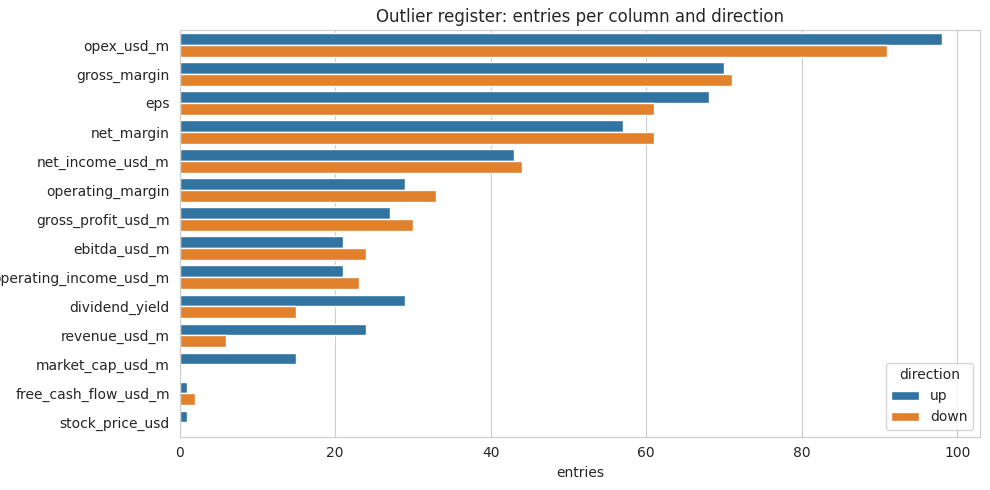

In [8]:
counts_figure = eda_figures.register_counts(register)

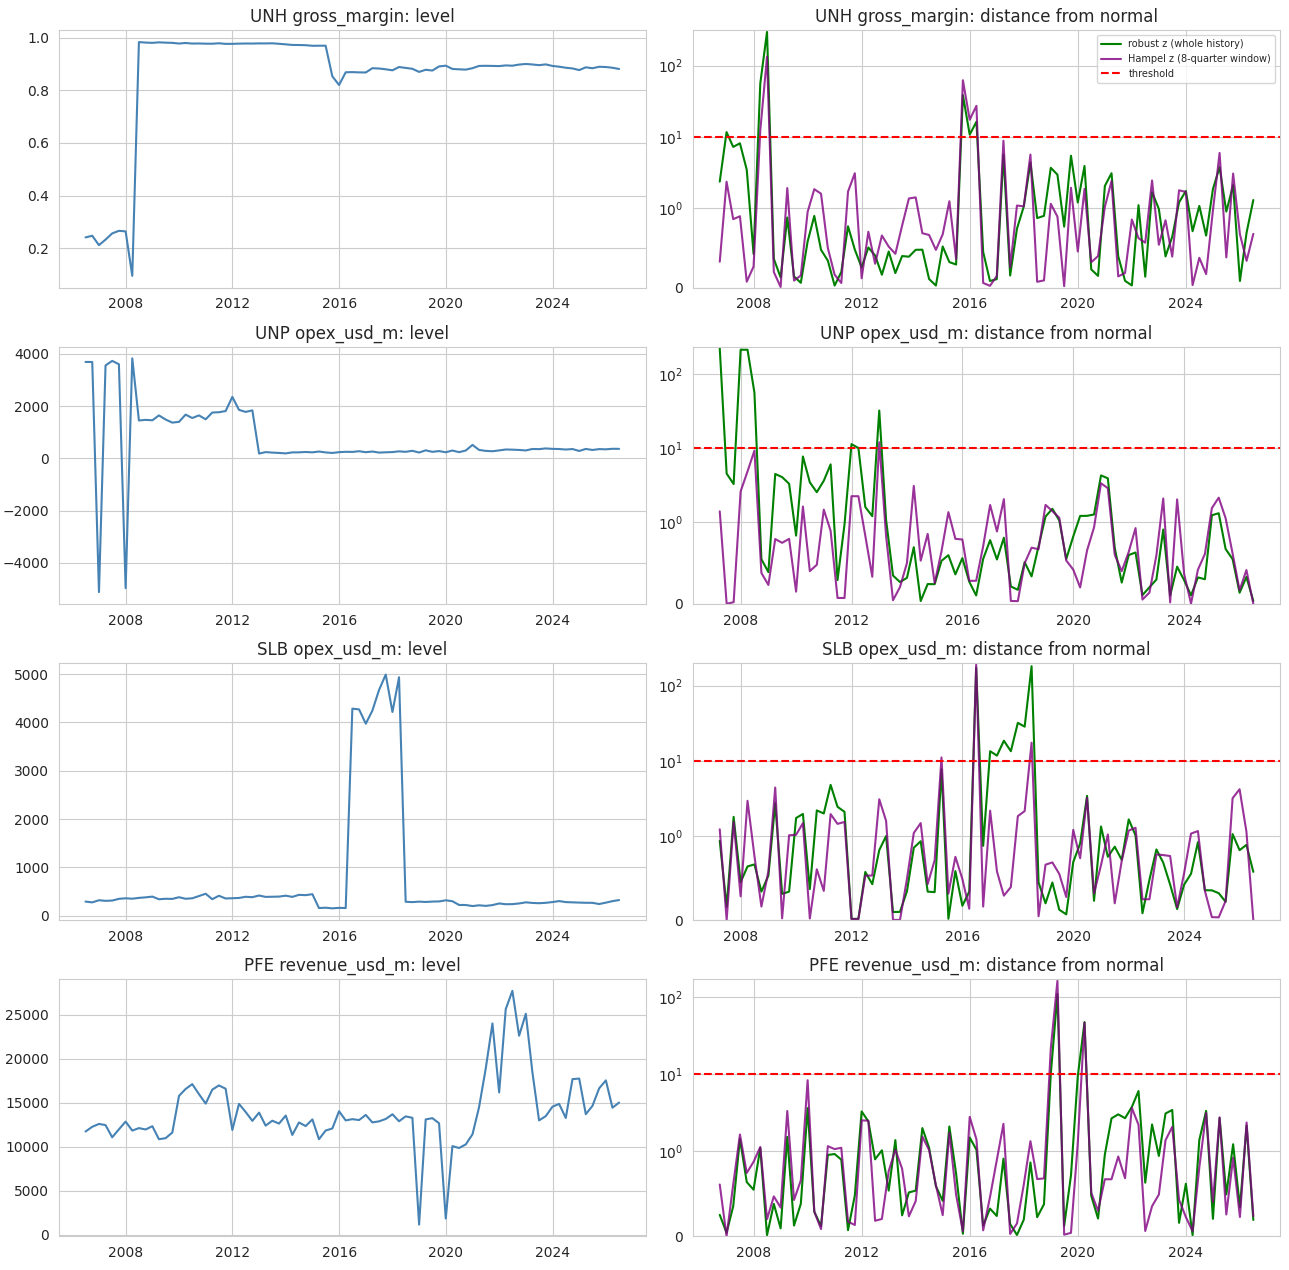

In [9]:
# The most extreme company-columns: the level, and each quarter's distance from
# normal; a spike above the red line is what put it in the register.
scores_figure = eda_figures.top_series_scores(register, panels)

In [10]:
with tracker.start_run(
    run_name(notebook="nb01", model="audit", variable="panel"),
    RunConfig(panel_size=len(panels), n_rows=n_rows),
    job_type="eda",
) as run:
    run.log_table("data_dictionary", data_dictionary)
    run.log_table("outlier_register", register)
    run.log_figure("register_counts", counts_figure)
    run.log_figure("register_top_series", scores_figure)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


**Answer (after the run):** read the dictionary for columns with a high missing share or any invalid sign; then the top of the register, most extreme first. Every top entry is either a data defect (add it to `config/ingestion_defects.yaml` with a spec) or an event (covered by the `covid` or `structural_break` flags); record which in § 9. The full register is in W&B (`nb01-audit-panel`) and in `nb01_outlier_register.csv`.

## 2. Target

**Question:** How is the chosen target distributed per arm and horizon, and which company-quarters are extreme?

The target is `y`, the transformed change the model will learn (spec F7): the three log arms for revenue, the revenue-scaled change for the other variables. Extremes are target values more than 10 robust standard deviations from their company's usual target.

In [11]:
target_frame = feature_service.target_frame(panels, horizons=(1, 2, 3, 4))
target_by_arm = target_frame.groupby(["arm", "horizon"])["y"]
target_summary = target_by_arm.agg(
    known="count", rows="size", median="median", skewness="skew"
)
target_summary["kurtosis"] = target_by_arm.apply(pd.Series.kurt)
target_summary["known_share"] = target_summary["known"] / target_summary["rows"]
target_extremes = diagnostics_service.register_target_extremes(target_frame)
target_summary.round(3)

known  rows  median  skewness  kurtosis  \
arm                horizon                                            
log_diff1          1         4708  4779   0.018    -0.380    39.157   
                   2         4649  4779   0.027     0.334    32.547   
                   3         4593  4779   0.034     2.891    73.784   
                   4         4534  4779   0.046     4.704   119.141   
log_diff4          1         4534  4779   0.046     4.704   119.141   
                   2         4534  4779   0.046     4.704   119.141   
                   3         4534  4779   0.046     4.704   119.141   
                   4         4534  4779   0.046     4.704   119.141   
seasnaive_residual 1         4472  4779  -0.001     0.834    65.800   
                   2         4413  4779  -0.000     1.177    48.594   
                   3         4357  4779  -0.000     0.154    49.195   
                   4         4298  4779  -0.000     0.442    33.886   

                            known_share  
arm                horizon               
log_diff1          1              0.985  
                   2              0.973  
                   3              0.961  
                   4              0.949  
log_diff4          1              0.949  
                   2              0.949  
                   3              0.949  
                   4              0.949  
seasnaive_residual 1              0.936  
                   2              0.923  
                   3              0.912  
                   4              0.899

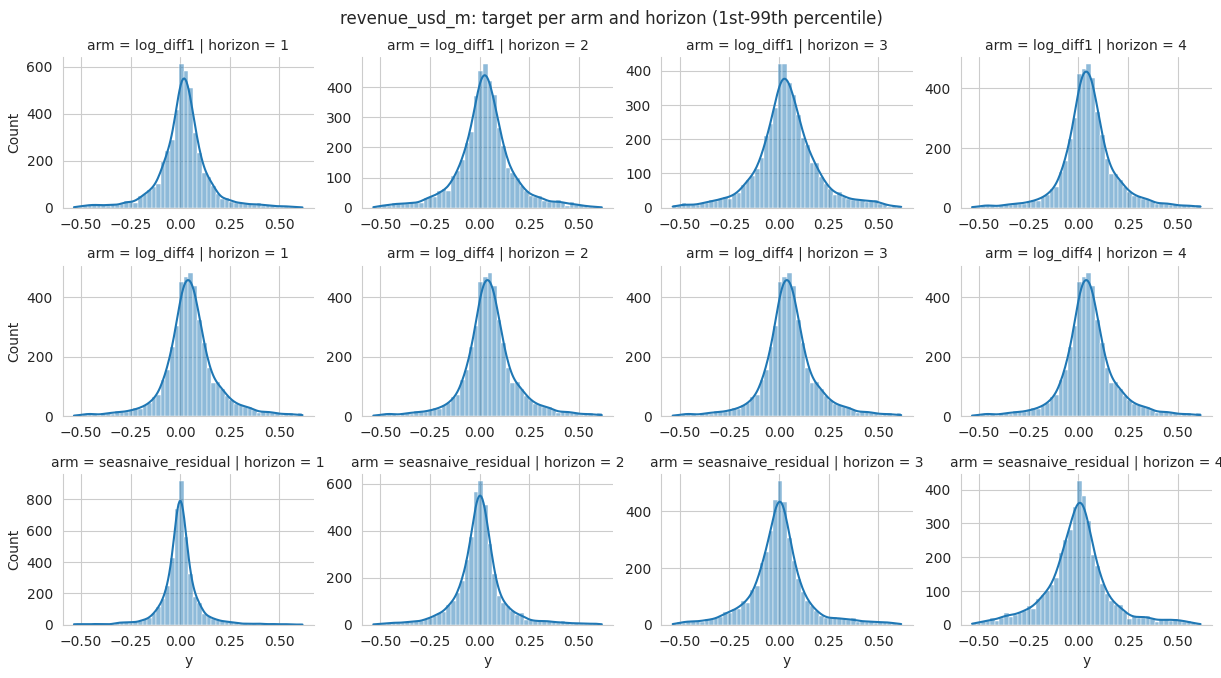

In [12]:
target_figure = eda_figures.target_distribution(
    target_frame, title=TARGET_VARIABLE.value
)

In [13]:
with tracker.start_run(
    run_name(notebook="nb01", model="target", variable=TARGET_VARIABLE.value),
    RunConfig(
        panel_size=len(panels), n_rows=n_rows, target_variable=TARGET_VARIABLE.value
    ),
    job_type="eda",
) as run:
    run.log_table("target_summary", target_summary.reset_index())
    run.log_table("target_extremes", target_extremes)
    run.log_figure("target_distribution", target_figure)

target_extremes.head(20).round({"y": 3, "robust_z": 1})

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


,ticker,date,arm,horizon,y,robust_z,direction
0,IBM,2021-09-30,seasnaive_residual,1,2.441,76.5,up
1,IBM,2019-12-31,seasnaive_residual,1,2.194,68.8,up
2,IBM,2019-09-30,seasnaive_residual,1,-2.189,-68.3,down
3,IBM,2021-12-31,seasnaive_residual,1,-2.086,-65.1,down
4,ORCL,2023-03-31,seasnaive_residual,1,-1.286,-42.0,down
5,ORCL,2018-06-30,seasnaive_residual,1,-1.279,-41.7,down
6,ORCL,2018-03-31,seasnaive_residual,1,1.220,39.6,up
7,KMB,2023-09-30,log_diff1,1,-1.114,-39.2,down
8,ORCL,2023-06-30,seasnaive_residual,1,1.205,39.1,up
9,KMB,2022-12-31,log_diff1,1,1.093,38.3,up


**Answer (after the run):** read three things.
- **Tails:** kurtosis far above 3 means a few quarters dominate; for revenue it runs 33–119, so robust methods and robust losses are warranted downstream.
- **Known share:** it falls with the horizon (each company's last `h` quarters have no target yet); `log_diff4` is the same at every horizon because its target is always growth against the same quarter a year earlier, seen from a different origin.
- **Extremes:** each is a defect or an event. For revenue the top is IBM 2019–2021, around the Kyndryl spin-off, and IBM is not in `config/structural_breaks.yaml`: a candidate row for § 9's decision table.

## 3. Numeric distributions

**Question:** How do the year-over-year changes of each company column spread, and how skewed and heavy-tailed are they?

Changes, not levels: pooled levels only show company size (spec F8). Positive columns change by their log, ratios by their plain difference, signed lines by their change over trailing revenue. P/E is left out (spec D11).

In [14]:
CHANGE_COLUMNS = [column for column in COMPANY_VALUE_COLUMNS if column != "pe_ratio"]
changes = pooled_yoy_changes(panels, [*CHANGE_COLUMNS, *MACRO_COLUMNS])
change_shape = pd.DataFrame({
    "skewness": changes[CHANGE_COLUMNS].skew(),
    "kurtosis": changes[CHANGE_COLUMNS].kurt(),
    "missing_share": changes[CHANGE_COLUMNS].isna().mean(),
})
change_shape.round(2)

,skewness,kurtosis,missing_share
revenue_usd_m,4.70,119.14,0.05
gross_profit_usd_m,-1.11,32.78,0.05
opex_usd_m,2.77,91.67,0.05
operating_income_usd_m,-1.80,28.67,0.05
ebitda_usd_m,0.55,57.87,0.05
net_income_usd_m,0.15,32.27,0.05
free_cash_flow_usd_m,-2.35,36.44,0.05
gross_margin,-0.84,163.61,0.05
operating_margin,67.32,4533.00,0.05
net_margin,67.32,4532.26,0.05


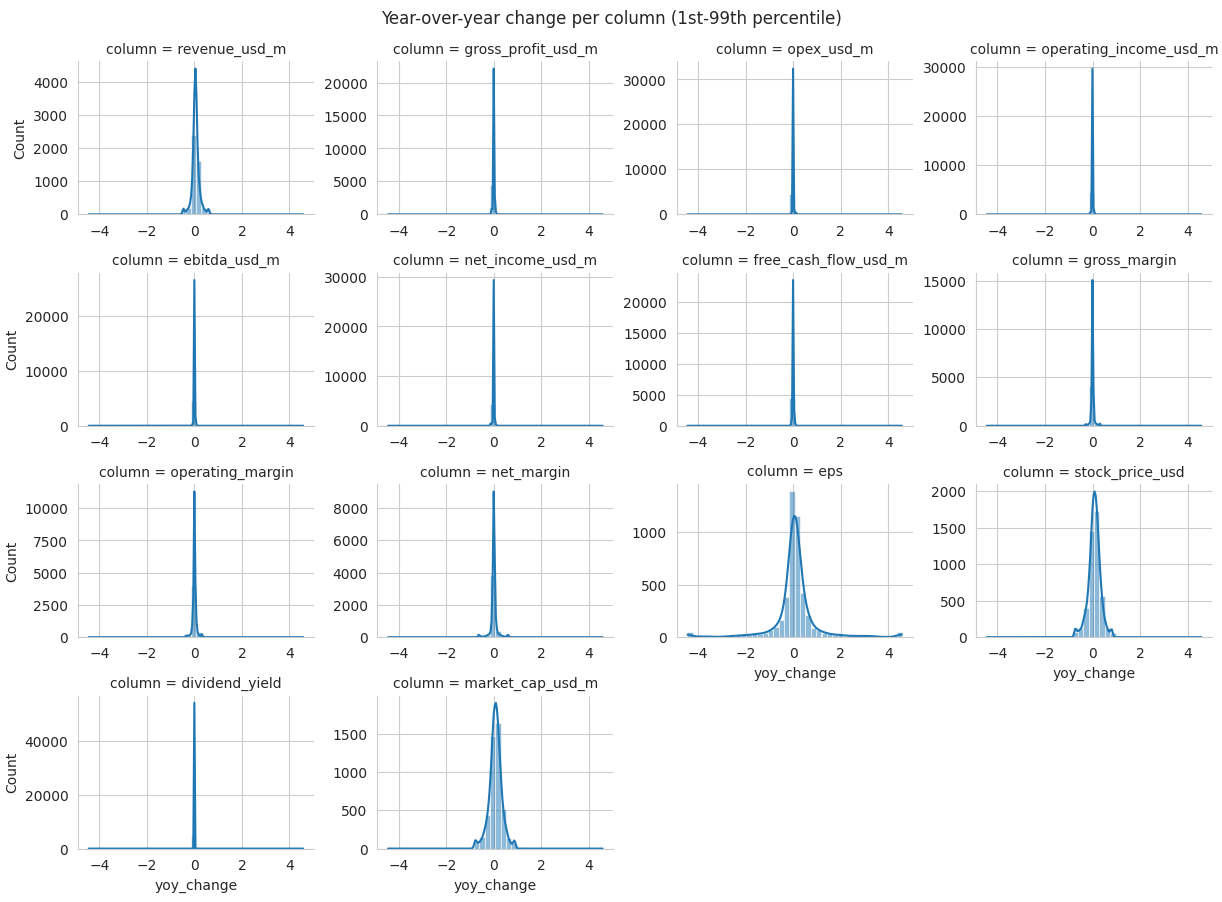

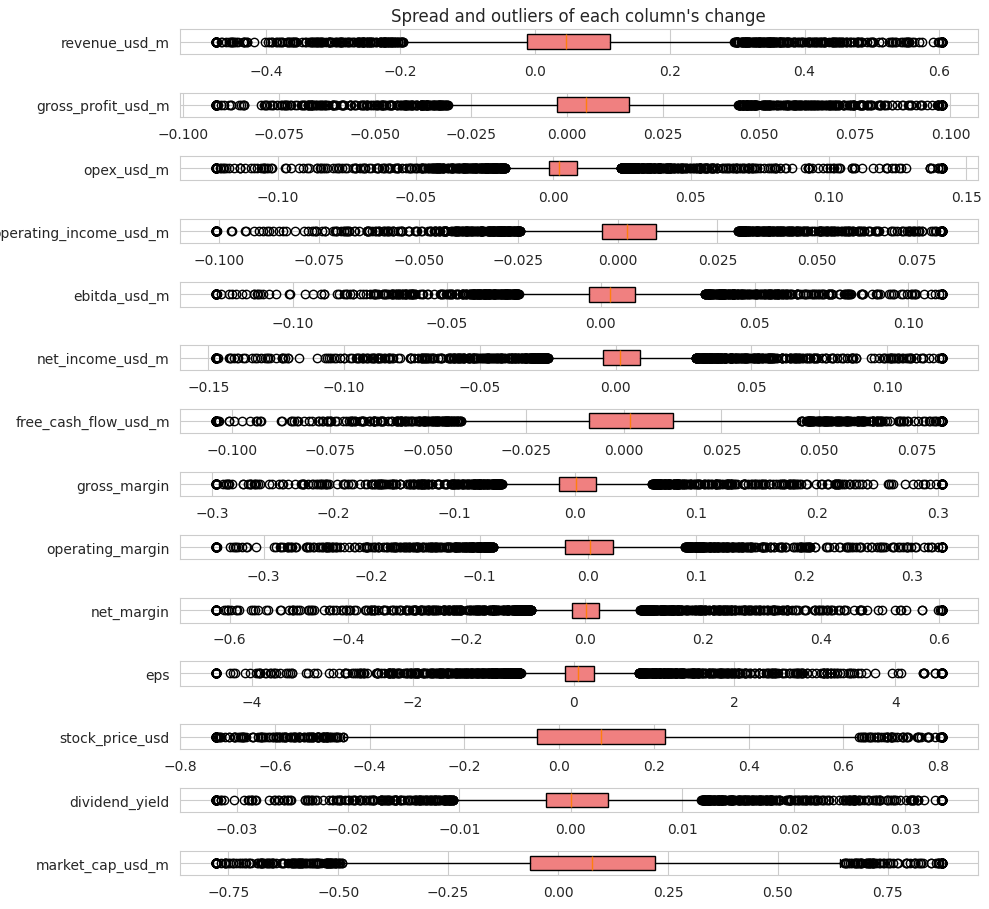

In [15]:
distribution_figure = eda_figures.change_distributions(changes[CHANGE_COLUMNS])
box_figure = eda_figures.change_boxplots(changes[CHANGE_COLUMNS])

**Answer (after the run):** kurtosis far above 3 marks heavy tails; for the real panel revenue's change is 119 and the operating and net margins' about 4,500, a handful of quarters where margins swing wildly (see § 1's register). A skewness beyond ±1 argues for the log or scaled change already used; a column whose box is mostly outliers is one to treat robustly downstream.

## 4. Categorical

**Question:** How are the companies spread across sectors and seasonality regimes, and is any group too small to compare?

A sector with fewer than three companies is flagged (spec F12): § 6 compares the target across segments, and a two-company segment is an anecdote.

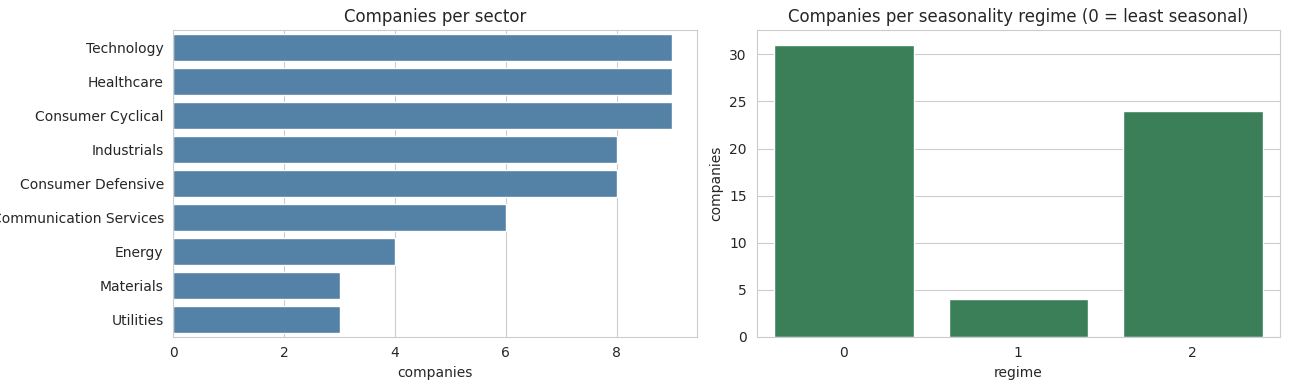

In [16]:
MIN_SEGMENT_COMPANIES = 3
company_sectors = pooled_panel.groupby("ticker")["sector"].first()
sector_companies = company_sectors.value_counts()
category_figure = eda_figures.categories(company_sectors, regimes)
thin_sectors = sector_companies[sector_companies < MIN_SEGMENT_COMPANIES]

**Answer (after the run):** the series under the plots lists any sector below three companies. On the real panel none is below, but Materials and Utilities sit exactly at three, so their comparisons in § 6 rest on thin evidence.

## 5. Correlations and redundancy

**Question:** Which columns move together, and which are redundant?

Spearman rank correlation of year-over-year changes (spec F9): levels correlate spuriously because everything grows over 20 years, and ranks resist the heavy tails seen in § 3. Pairs above |ρ| = 0.85 are listed as redundant (spec D6).

,left,right,rho
0,stock_price_usd,market_cap_usd_m,0.959
1,net_income_usd_m,net_margin,0.913
2,operating_income_usd_m,operating_margin,0.882
3,net_income_usd_m,eps,0.879
4,operating_income_usd_m,ebitda_usd_m,0.875


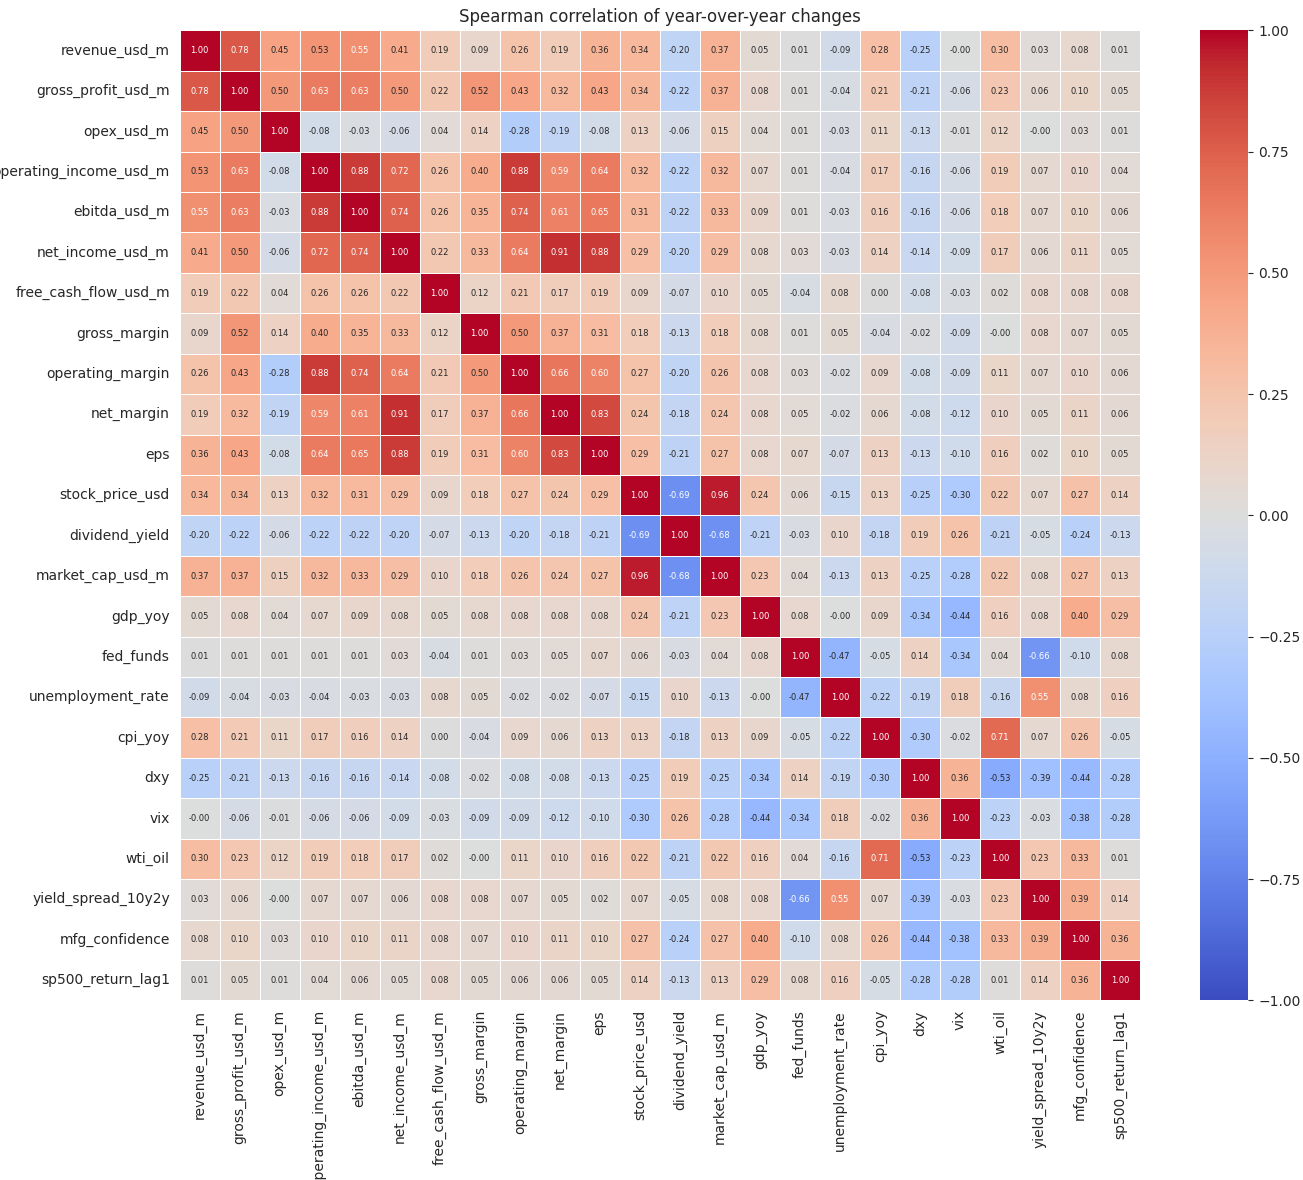

In [17]:
correlation_analyzer = container.correlation_analyzer()
correlation_columns = [*CHANGE_COLUMNS, *MACRO_COLUMNS]
correlations = correlation_analyzer.matrix(changes[correlation_columns])
redundant_pairs = correlation_analyzer.redundant_pairs(correlations)

heatmap_figure = eda_figures.correlation_heatmap(correlations)
redundant_pairs.round(3)

In [18]:
with tracker.start_run(
    run_name(notebook="nb01", model="distributions", variable="panel"),
    RunConfig(panel_size=len(panels), n_rows=n_rows),
    job_type="eda",
) as run:
    run.log_table("change_shape", change_shape.reset_index(names="column"))
    run.log_table("redundant_pairs", redundant_pairs)
    run.log_figure("change_distributions", distribution_figure)
    run.log_figure("change_boxplots", box_figure)
    run.log_figure("categories", category_figure)
    run.log_figure("correlation_heatmap", heatmap_figure)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


**Answer (after the run):** each redundant pair is a candidate to drop one side from the features (§ 9's feature-group row). On the real panel the pairs are stock price ↔ market cap (0.97), net income ↔ net margin (0.91), operating income ↔ operating margin (0.88), net income ↔ EPS (0.86) and operating income ↔ EBITDA (0.86): each is one quantity measured twice.

## 6. Segments against the target

**Question:** Does the target behave differently by sector, seasonality regime or covid period?

The headline view: the chosen variable's default arm at horizon 1. Periods follow NB00's `covid` flag, before it, the flagged quarters and after it (spec F10, D7).

,segment,value,companies,observations,median,lower_quartile,upper_quartile
0,sector,Communication Services,6,456,0.000,-0.024,0.024
1,sector,Consumer Cyclical,9,674,-0.002,-0.040,0.031
2,sector,Consumer Defensive,8,608,-0.002,-0.024,0.020
3,sector,Energy,4,304,0.004,-0.085,0.087
4,sector,Healthcare,9,684,0.000,-0.033,0.033
5,sector,Industrials,8,608,-0.003,-0.044,0.042
6,sector,Materials,3,228,0.001,-0.024,0.027
7,sector,Technology,9,682,-0.001,-0.037,0.036
8,sector,Utilities,3,228,0.001,-0.058,0.068
9,regime,0,31,2355,-0.001,-0.036,0.033


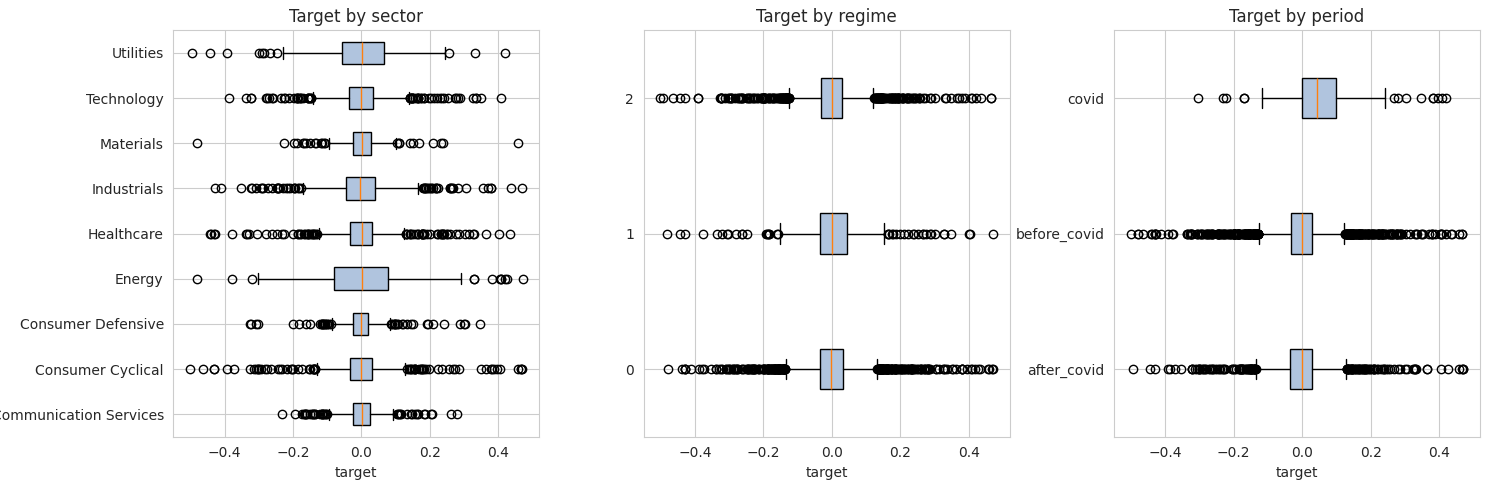

In [19]:
SEGMENTS = ["sector", "regime", "period"]
headline = target_frame[
    (target_frame["arm"] == default_arm(TARGET_VARIABLE).value)
    & (target_frame["horizon"] == 1)
]
segments = segment_frame(headline, panels, regimes)
segment_table = container.segment_profiler().by_segment(segments, SEGMENTS)
segment_figure = eda_figures.segment_boxplots(segments, SEGMENTS)
segment_table.round(3)

**Answer (after the run):** a segment whose median or quartiles sit clearly apart from the others is a signal the model should see: sector and regime are already features (group S), and a distinct covid period argues for keeping the `covid` flag (group F). § 9 turns the regime comparison into the pooled-or-segmented decision with a Kruskal-Wallis test.

## 7. Time: stationarity, seasonality, trend

**Question:** Does each series trend, wander or repeat seasonally, and is its growth predictable from its past? (Seasonal profiles per regime and the panel timeline are added in plan Task 8.)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


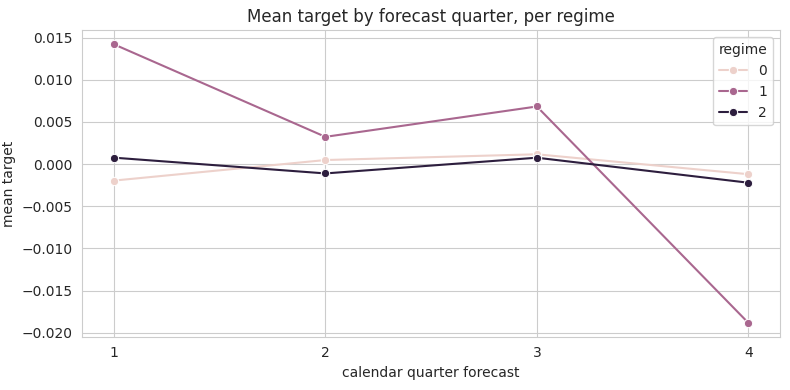

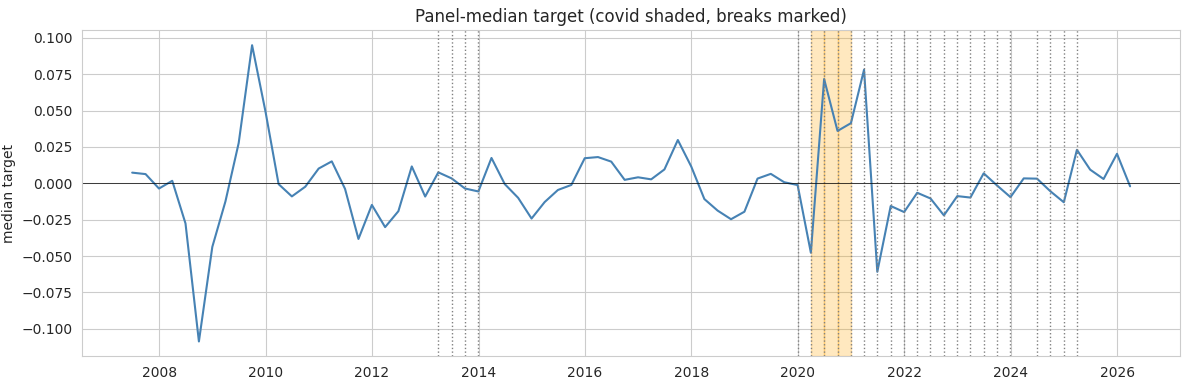

In [20]:
seasonal_profile_figure = eda_figures.seasonal_profile(seasonal_profile(segments))
timeline_figure = eda_figures.median_timeline(median_timeline(segments))

with tracker.start_run(
    run_name(notebook="nb01", model="segments", variable=TARGET_VARIABLE.value),
    RunConfig(
        panel_size=len(panels), n_rows=n_rows, target_variable=TARGET_VARIABLE.value
    ),
    job_type="eda",
) as run:
    run.log_table("target_by_segment", segment_table)
    run.log_figure("target_by_segment", segment_figure)
    run.log_figure("seasonal_profile", seasonal_profile_figure)
    run.log_figure("median_timeline", timeline_figure)

**Seasonal profile and timeline:** the profile shows each regime's typical target in each calendar quarter it forecasts, so a flat line for regime 0 and a pronounced one for regime 2 confirm the clustering. The timeline shows the panel's typical target over time: covid quarters are shaded, structural breaks marked; a level shift after a break is what the `structural_break` flag must explain.

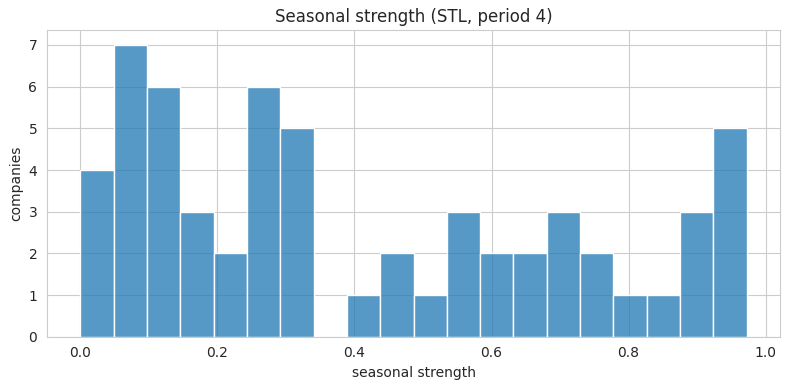

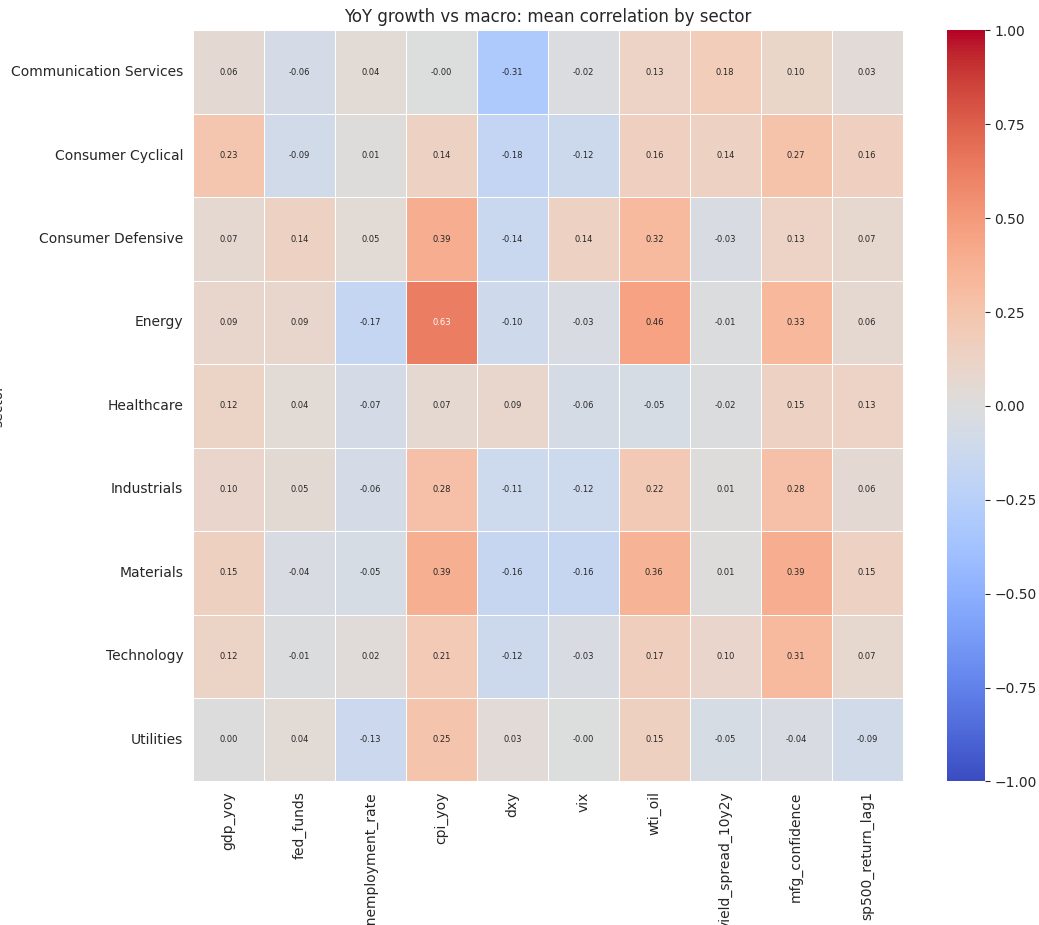

In [21]:
seasonal_figure = eda_figures.seasonal_strength(revenue)
differencing_orders = pd.crosstab(
    revenue["d_levels"], revenue["d_log"], rownames=["d_levels"], colnames=["d_log"]
)
sensitivity_figure = eda_figures.sector_sensitivity(sector_sensitivity)

In [22]:
for variable in TARGETS:
    config = RunConfig(panel_size=len(panels), n_rows=n_rows, target_variable=variable)
    with tracker.start_run(
        run_name(notebook="nb01", model="eda", variable=variable),
        config,
        job_type="eda",
    ) as run:
        run.log_table("diagnostics", diagnostics.query("variable == @variable"))
        if variable == "revenue_usd_m":
            run.log_table("seasonality_regimes", regimes.reset_index())
            run.log_table("differencing_orders", differencing_orders.reset_index())
            run.log_table(
                "macro_sensitivity_by_sector", sector_sensitivity.reset_index()
            )
            run.log_figure("seasonal_strength", seasonal_figure)
            run.log_figure("macro_sensitivity_heatmap", sensitivity_figure)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [23]:
appendix_c = pd.DataFrame(
    {
        "d_levels": [1, 2, 2, 2, 1, 2],
        "d_log": [0, 2, 1, 1, 2, 2],
        "seasonal_strength": [0.933, 0.908, 0.279, 0.770, 0.961, 0.577],
    },
    index=["AAPL", "AMZN", "GOOGL", "MSFT", "PEP", "PG"],
)
comparison = revenue.loc[
    appendix_c.index, ["d_levels", "d_log", "seasonal_strength"]
].join(appendix_c, rsuffix="_appendix_c")
comparison["seasonal_gap"] = (
    comparison["seasonal_strength"] - comparison["seasonal_strength_appendix_c"]
).abs()
assert comparison["seasonal_gap"].le(0.05).all()  # A3
comparison.round(3)

,d_levels,d_log,seasonal_strength,d_levels_appendix_c,d_log_appendix_c,seasonal_strength_appendix_c,seasonal_gap
AAPL,1.0,1.0,0.933,1,0,0.933,0.0
AMZN,2.0,2.0,0.908,2,2,0.908,0.0
GOOGL,2.0,1.0,0.279,2,1,0.279,0.0
MSFT,2.0,1.0,0.770,2,1,0.770,0.0
PEP,1.0,2.0,0.961,1,2,0.961,0.0
PG,2.0,2.0,0.577,2,2,0.577,0.0


### A3 — agreement with master plan Appendix C

Seasonal strength matches Appendix C to three decimals for all six companies, and `d_levels` matches for all six. `d_log` matches for five.

**AAPL `d_log`: 1 here, 0 in Appendix C.** On AAPL log revenue at d = 0, ADF rejects a unit root (p = 0.034) but KPSS rejects stationarity (p = 0.01, clipped at the table bound). Spec R3 requires both tests to agree, so the rule moves on to d = 1. Appendix C's 0 is what ADF alone gives. The difference is the decision rule, not the data; it is recorded here, not tuned away (spec A3).

TSLA is left out on purpose: Appendix C's n = 75 came from dropping NaN across gaps, which R2 forbids.

## 8. Features: build, audit, export

**Question:** Do the features use only information known at each origin, does every target arm invert exactly, and which features carry signal?

In [24]:
for horizon in (1, 2, 3, 4):
    for panel in panels.values():
        feature_service.check_lookahead(
            panel, horizon=horizon, origins=[8, 20, 40, 60], regimes=regimes
        )  # A4

In [25]:
apple_revenue = panels["AAPL"]["revenue_usd_m"]
for arm in TargetArm:
    for horizon in (1, 2, 3, 4):
        transformer = TargetTransformer(arm=arm, horizon=horizon)
        target = transformer.make(apple_revenue, revenue=apple_revenue)
        rebuilt = transformer.reconstruct(apple_revenue, target, revenue=apple_revenue)
        actual = apple_revenue.shift(-horizon)
        known = rebuilt.notna() & actual.notna()
        np.testing.assert_allclose(rebuilt[known], actual[known], rtol=1e-9)  # A5

### Export

One parquet per target variable and horizon (`features_{variable}_h{h}.parquet`), with the variable's default arm (`seasnaive_residual` for revenue, `revenue_scaled_yoy` for the others), every origin row kept: `y` is NaN for each company's last `h` quarters (spec R8).

In [26]:
ARM = default_arm(TARGET_VARIABLE)
# The default spec builds every group, so every mapped column is a feature.
n_features = len(feature_groups_by_column())

config = RunConfig(
    panel_size=len(panels),
    n_rows=n_rows,
    target_variable=TARGET_VARIABLE.value,
    target_transform=ARM.value,
    feature_groups=tuple(sorted(group.value for group in FeatureGroup)),
    n_features=n_features,
)
with tracker.start_run(
    run_name(notebook="nb02", model="features", variable=TARGET_VARIABLE.value),
    config,
    job_type="features",
) as run:
    export_summary = []
    datasets = {}
    for horizon in (1, 2, 3, 4):
        dataset = feature_service.assemble(
            panels, horizon=horizon, arm=ARM, regimes=regimes
        )
        datasets[horizon] = dataset
        labelled_rows = int(dataset["y"].notna().sum())
        assert len(dataset) == n_rows - n_pre_listing  # A6
        assert labelled_rows <= n_rows - len(panels) * horizon  # A6
        run.log_dataset(
            f"features_{TARGET_VARIABLE.value}_h{horizon}",
            feature_store.write(dataset, TARGET_VARIABLE.value, horizon),
        )
        export_row = {
            "horizon": horizon,
            "rows": len(dataset),
            "labelled_rows": labelled_rows,
            "unlabelled_rows": len(dataset) - labelled_rows,
        }
        run.log_metrics({**export_row, "n_features": n_features})
        export_summary.append(export_row)
    run.log_table("export_summary", pd.DataFrame(export_summary))
pd.DataFrame(export_summary)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


horizon,▁▃▆█
labelled_rows,█▆▃▁
n_features,▁▁▁▁
rows,▁▁▁▁
unlabelled_rows,▁▃▆█
horizon,4
labelled_rows,4292
n_features,30
rows,4763
unlabelled_rows,471


,horizon,rows,labelled_rows,unlabelled_rows
0,1,4763,4468,295
1,2,4763,4409,354
2,3,4763,4351,412
3,4,4763,4292,471


### Feature audit

**Question:** Which features carry signal about the target, which groups earn their place, and which features repeat each other?

Per feature, over the labelled rows: the share missing, the Spearman correlation with `y` (monotone links), and the mutual information with `y` (any link; categorical features too). Pairs above the redundancy threshold are listed once.


100%|██████████| 33/33 [00:00<00:00, 177.08it/s]
c:\Users\leona\source\repos\CFO_Copilot\.venv\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6 9 0 ... 0 3 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


,h1,h2,h3,h4
feature,,,,
covid,0.010,0.021,0.016,0.011
cpi_yoy,0.073,0.109,0.093,0.107
dxy,0.056,0.088,0.068,0.084
fed_funds,0.049,0.064,0.070,0.088
gdp_yoy,0.081,0.099,0.081,0.085
gross_margin,0.019,0.017,0.021,0.041
growth_yoy_lag1,0.122,0.193,0.279,0.387
growth_yoy_lag2,0.081,0.177,0.252,0.205
growth_yoy_lag3,0.079,0.163,0.120,0.113


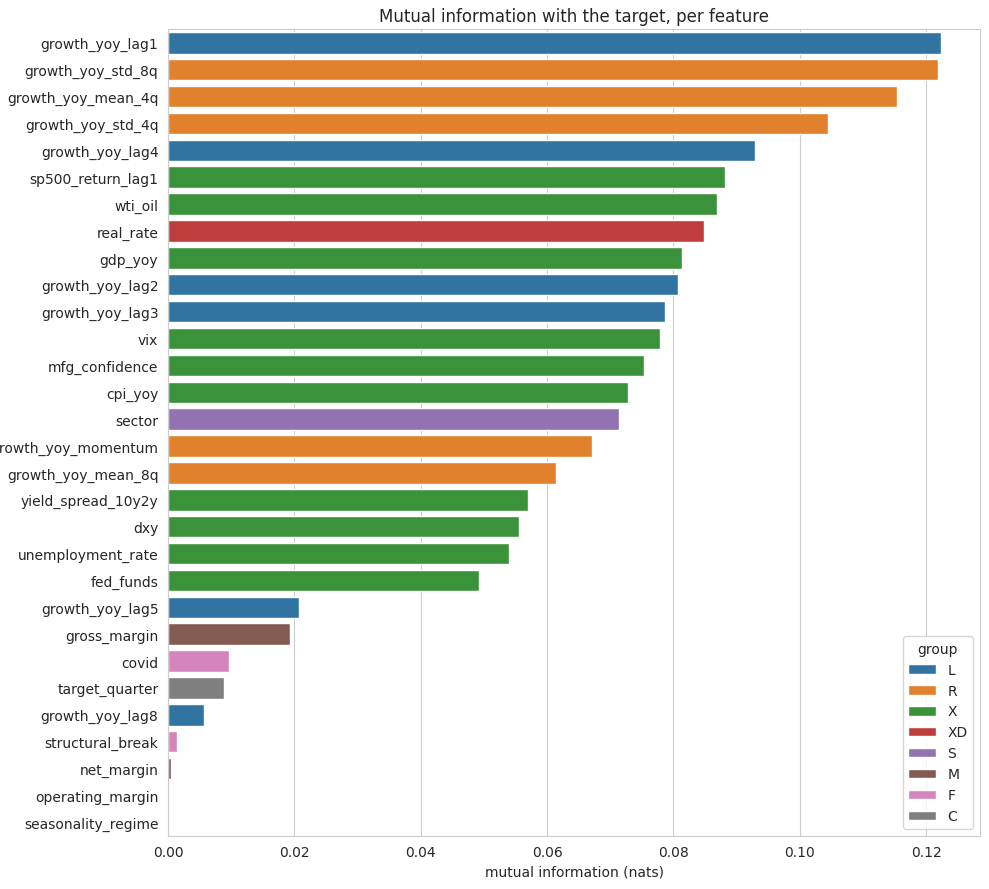

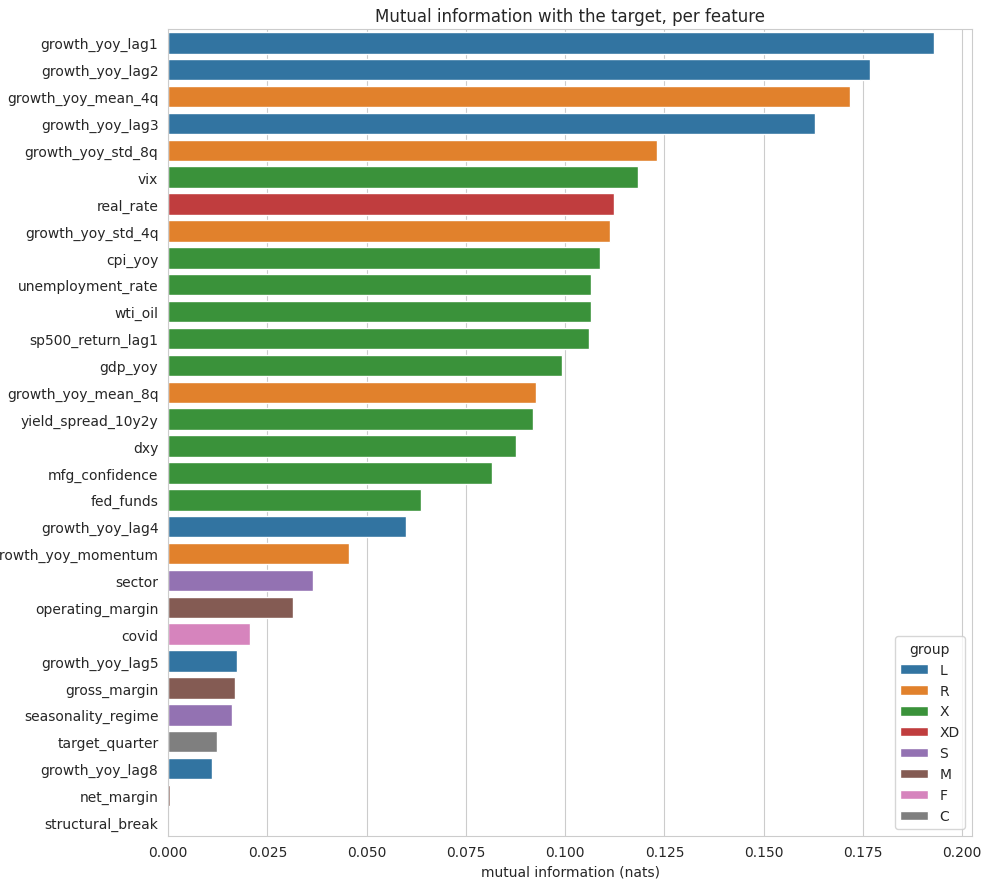

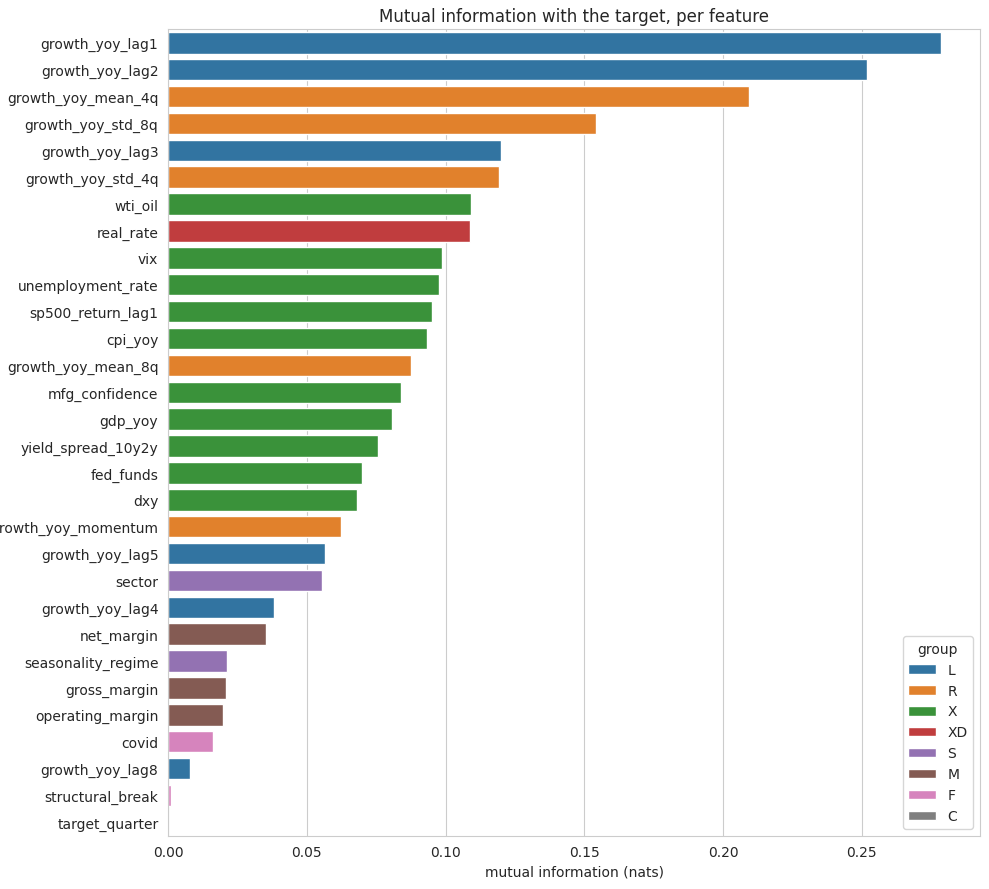

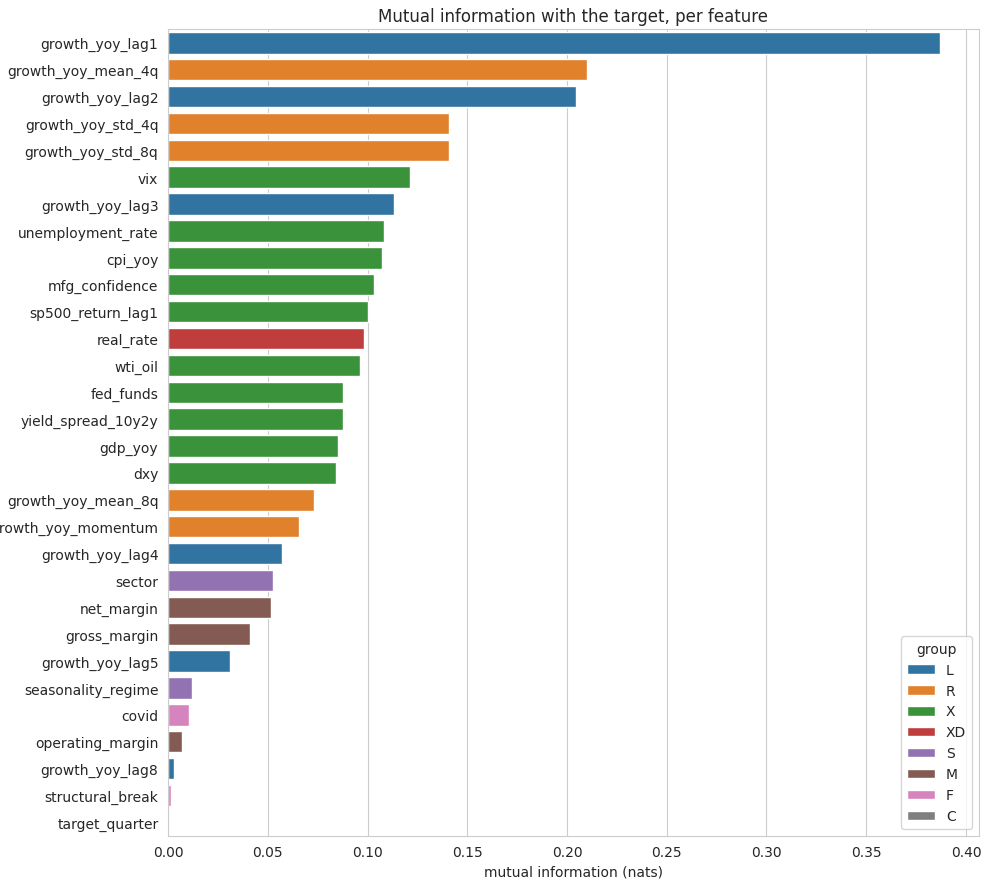

In [27]:
feature_auditor = container.feature_auditor()
audits = {
    horizon: feature_auditor.audit(dataset, groups=feature_groups_by_column())
    for horizon, dataset in datasets.items()
}
features_report = auto_profiler.profile(
    datasets[1].drop(columns=["origin_date", "target_date"]),
    title=f"NB01 features ({TARGET_VARIABLE.value}, h1)",
    name=f"nb01_auto_eda_features_{TARGET_VARIABLE.value}.html",
)
with tracker.start_run(
    run_name(notebook="nb01", model="autoeda-features", variable=TARGET_VARIABLE.value),
    config,
    job_type="eda",
) as run:
    run.log_html("auto_eda_features", features_report)
    for horizon, audit in audits.items():
        run.log_table(f"feature_scores_h{horizon}", audit.features)
        run.log_table(f"feature_groups_h{horizon}", audit.groups)
        run.log_table(f"redundant_features_h{horizon}", audit.redundant_pairs)
        ranking_figure = eda_figures.feature_ranking(audit.features)
        run.log_figure(f"feature_ranking_h{horizon}", ranking_figure)
pd.DataFrame({
    f"h{horizon}": audit.features.set_index("feature")["mutual_information"]
    for horizon, audit in audits.items()
}).round(3)

In [28]:
audits[1].groups.round(3)

,group,features,mean_mutual_information,best_mutual_information,mean_missing_share
0,L,6,0.067,0.122,0.037
1,R,5,0.094,0.122,0.055
2,X,10,0.070,0.088,0.000
3,XD,1,0.085,0.085,0.000
4,S,2,0.036,0.071,0.000
5,M,3,0.007,0.019,0.000
6,F,2,0.006,0.010,0.000
7,C,1,0.009,0.009,0.000


In [29]:
audits[1].redundant_pairs.round(3)

,left,right,rho
0,operating_margin,net_margin,0.883
1,unemployment_rate,yield_spread_10y2y,0.877
2,growth_yoy_lag2,growth_yoy_mean_4q,0.877
3,growth_yoy_lag3,growth_yoy_mean_4q,0.861


**Answer** (revenue, `seasnaive_residual`; h1 and h4 from a dry run):

- **Own history carries the most signal.** `growth_yoy_lag1` ranks first at both horizons (mutual information 0.13 at h1, 0.39 at h4), with a *negative* Spearman correlation (−0.32, −0.60): growth above last year's tends to revert. Lags and rolling statistics (L, R) lead the group summary.
- **Macro mutual information is overstated.** Every macro feature has one value per quarter, shared by all companies, so it acts as a date label: its mutual information (0.05–0.12) picks up the quarter's common shock, while its Spearman correlation stays near 0 (`cpi_yoy`, `wti_oil` and `real_rate` reach about 0.2–0.3 at h4). Judge macro groups by out-of-sample error in NB02, not by this score.
- **Weak groups:** margins (M), calendar (C), flags (F) and `seasonality_regime` score near 0. They stay in for now, since tree models and the regime split may still use them; the ablation in NB02 decides.
- **Redundant pairs (|ρ| > 0.85):** `operating_margin` and `net_margin`; `unemployment_rate` and `yield_spread_10y2y`; `growth_yoy_lag2` and `lag3` with `growth_yoy_mean_4q`. Linear models keep only one of each pair.
- **Missing values:** the 8-quarter lag and window features miss about 9% (each company's first two years); everything else is complete.


## 9. Summary and decision table

**Question:** What did the EDA find, and what do we decide for the chosen target: transform, exclusions, feature groups, pooled or segmented, forecastable?

Each row applies one rule from spec F14 to this run's results (thresholds D3–D5: mutual-information floor 0.005, significance 0.05, forecastable when at least half the companies show Ljung-Box p < 0.05). The table is logged to W&B as `nb01-decisions-{variable}`.


In [30]:
decision_table = pd.DataFrame([
    row.model_dump()
    for row in container.decision_table_builder().build(
        DecisionInputs(
            variable=TARGET_VARIABLE,
            excluded_companies=ingestion_defects.excluded_companies,
            register=register,
            feature_groups=audits[1].groups,
            dataset=datasets[1],
            ljung_box_p=diagnostics.query(
                "variable == @TARGET_VARIABLE.value"
            ).set_index("ticker")["ljung_box_p"],
        )
    )
])
with tracker.start_run(
    run_name(notebook="nb01", model="decisions", variable=TARGET_VARIABLE.value),
    config,
    job_type="eda",
) as run:
    run.log_table("decision_table", decision_table)
decision_table.set_index("decision")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\leona\_netrc


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


,finding,evidence,action,applies_to
decision,,,,
target_transform,"arms available: log_diff1, log_diff4, seasnaiv...",F3: log arms only for a variable that is never...,export seasnaive_residual; compare the arms in...,revenue_usd_m
exclusions,"1 excluded by an ingestion spec, 0 with a non-...",ingestion defects: COP; sign rule: 0 register ...,exclude COP,revenue_usd_m
feature_groups,0 of 8 groups below the floor,"best mutual information per group: L 0.122, R ...",keep every group,revenue_usd_m
pooled_or_segmented,no difference across regimes,Kruskal-Wallis p = 0.822 over 3 regimes,pooled: one model for every company,revenue_usd_m
forecastable,53 of 59 companies show autocorrelation,Ljung-Box p < 0.05: 90% (bar 50%),forecastable: carry to NB02,revenue_usd_m


### Summary (article Step 8)

From a dry run on revenue (`seasnaive_residual`, h1), with EBITDA and free cash flow for comparison; re-read after each run.

1. **Dataset overview.** 59 companies (60 from NB00, COP excluded) × 81 quarters, 2006–2026; 10 macro series shared by every company; 30 features in 8 groups.
2. **Data quality.** COP is excluded and opex is blocked until `ingestion-defects-cop-ge.md` lands. The outlier register's top entries are events, not defects, except for the candidates in § 1 (UNH 2008, UNP opex 2007–08, SLB opex 2016–18, PFE revenue 2019-Q1). IBM's Kyndryl spin-off (2021) is missing from `structural_breaks.yaml`. No revenue is non-positive.
3. **Distributions.** Every change is heavy-tailed (revenue kurtosis 33–119), so robust scores and robust losses downstream. The covid quarters (2020-Q2 to Q4) pull the panel median down by 0.044. Materials and Utilities have only three companies each.
4. **Correlations and relationships.** A company's own recent growth predicts best (`growth_yoy_lag1`, Spearman −0.32 at h1, −0.60 at h4: mean reversion). Five redundant column pairs in § 5 and four feature pairs in § 8; linear models keep one side of each. Macro features score through the quarter they identify, not through a monotone link.
5. **Feature-engineering hypotheses for NB02.** Drop or merge one side of each redundant pair for linear models; an ablation of the weak groups (flags, calendar, and for free cash flow the real rate); a structural-break flag for IBM 2021; macro factors (a principal-component summary of the 10 macro series) only if the macro group survives the ablation.
6. **Open questions.** Are the § 1 defect candidates real defects? Should IBM 2021 be a structural break?

**Decisions (revenue):** export `seasnaive_residual` and compare the log arms in NB02; exclude COP; keep every feature group (flags score 0.009, above the 0.005 floor of D3); pooled, since the target does not differ across regimes (Kruskal-Wallis p = 0.83); forecastable, with 53 of 59 companies autocorrelated (90%). EBITDA and free cash flow give the same pooled and forecastable decisions (p = 0.078 and 0.13; 88% and 95%); their drop candidates are flags and calendar, plus the real rate for free cash flow.
